# **STEP 1: Install Required Libraries**

In [ ]:
# =========================================================
# STEP 1: INSTALL REQUIRED LIBRARIES
# =========================================================

!pip install tensorflow
!pip install matplotlib seaborn
!pip install pillow
!pip install scikit-learn

print("All libraries installed successfully ")

All libraries installed successfully 


# **STEP 2: Import Libraries**

In [ ]:
# =========================================================
# STEP 2: IMPORT REQUIRED LIBRARIES
# =========================================================

# Core libraries
import os
import numpy as np
import pandas as pd

# Image processing
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully ")

All libraries imported successfully 


# **STEP 3: Mount Google Drive**

In [ ]:
# =========================================================
# STEP 3: MOUNT GOOGLE DRIVE
# =========================================================

from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully ")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully 


# **STEP 4: Define Dataset Path**

In [ ]:
# =========================================================
# STEP 4: DEFINE DATASET PATH
# =========================================================

dataset_path = "/content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Dataset"

print("Dataset Path:", dataset_path)

# Check if path exists
print("Path Exists:", os.path.exists(dataset_path))

Dataset Path: /content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Dataset
Path Exists: True


# **STEP 5: Check Dataset Classes (Folders)**

In [ ]:
# =========================================================
# STEP 5: CHECK DATASET CLASSES
# =========================================================

classes = os.listdir(dataset_path)

print("Classes in Dataset:")
for c in classes:
    print("", c)

Classes in Dataset:
 MildDemented
 ModerateDemented
 NonDemented
 VeryMildDemented


# **STEP 6: Count Images in Each Class**

In [ ]:
# =========================================================
# STEP 6: COUNT IMAGES IN EACH CLASS
# =========================================================

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    num_images = len(os.listdir(class_path))

    print(f"{class_name} : {num_images} images")

MildDemented : 1000 images
ModerateDemented : 1000 images
NonDemented : 1000 images
VeryMildDemented : 1000 images


# **STEP 7: Display Sample Images**

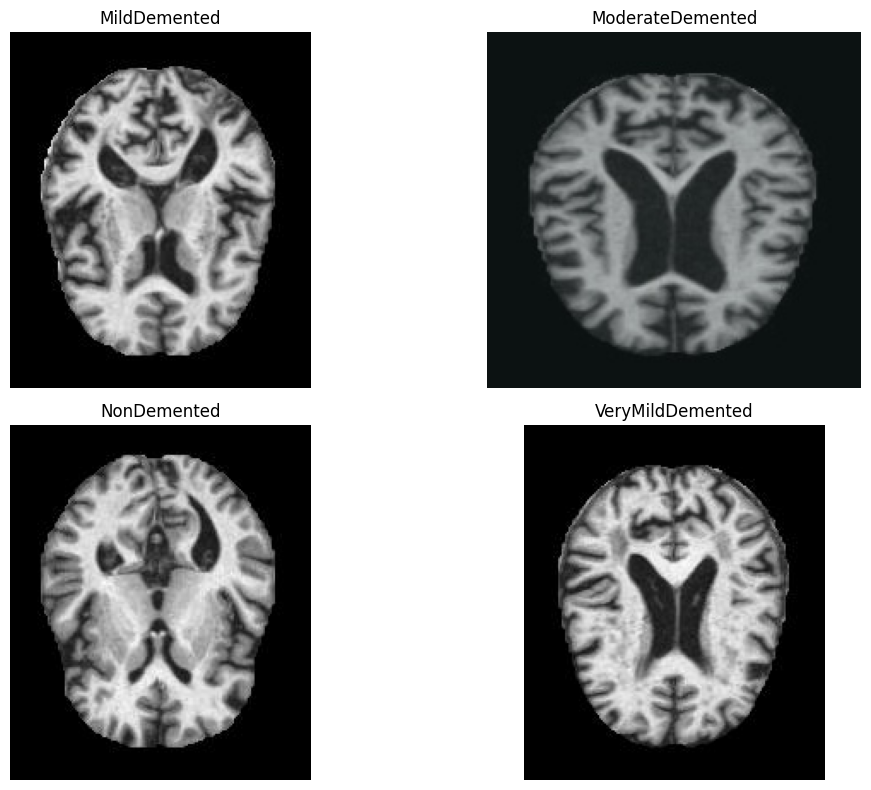

In [ ]:
# =========================================================
# STEP 7: DISPLAY SAMPLE IMAGES
# =========================================================

import random

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    # Pick random image
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    # Load image
    img = Image.open(img_path).convert('RGB')

    # Plot
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

# **STEP 8: Convert Dataset into DataFrame**

In [ ]:
# =========================================================
# STEP 8: CREATE DATAFRAME FROM DATASET
# =========================================================

data = []

for folder_name in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder_name)

    if os.path.isdir(folder_path):
        for img_name in os.listdir(folder_path):
            data.append({
                'FilePath': os.path.join(folder_path, img_name),
                'Label': folder_name
            })

# Convert to DataFrame
df = pd.DataFrame(data)

print("Total images:", len(df))
df.head()

Total images: 4000


,FilePath,Label
0,/content/drive/MyDrive/2026 M.Tech Projects/Al...,MildDemented
1,/content/drive/MyDrive/2026 M.Tech Projects/Al...,MildDemented
2,/content/drive/MyDrive/2026 M.Tech Projects/Al...,MildDemented
3,/content/drive/MyDrive/2026 M.Tech Projects/Al...,MildDemented
4,/content/drive/MyDrive/2026 M.Tech Projects/Al...,MildDemented


# **STEP 9: Visualize Class Distribution**

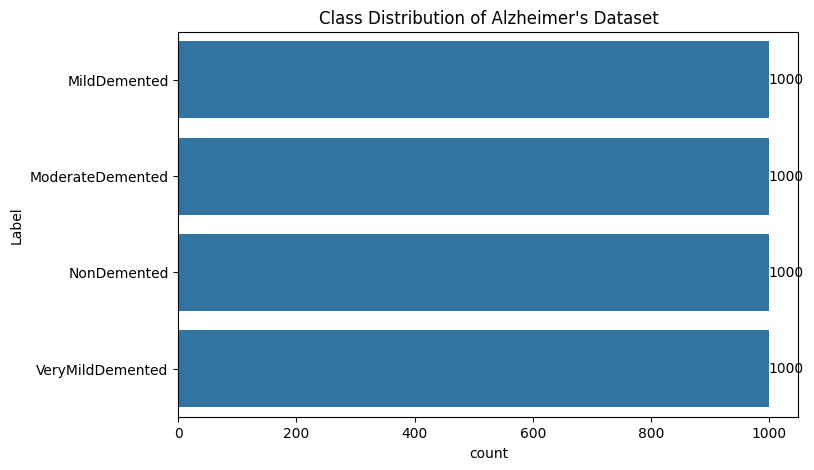

In [ ]:
# =========================================================
# STEP 9: CLASS DISTRIBUTION VISUALIZATION
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(data=df, y='Label', order=df['Label'].value_counts().index)

plt.title("Class Distribution of Alzheimer's Dataset")

# Show numbers on bars
ax = plt.gca()
ax.bar_label(ax.containers[0])

plt.show()

# **STEP 10: Split Dataset (Train / Validation / Test)**

In [ ]:
# =========================================================
# STEP 10: SPLIT DATASET
# =========================================================

from sklearn.model_selection import train_test_split

# First split → Train + Test
train_val_df, test_df = train_test_split(
    df,
    test_size=0.10,
    stratify=df['Label'],   # VERY IMPORTANT (keeps balance)
    random_state=42
)

# Second split → Train + Validation
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1111,  # gives ~10% of total
    stratify=train_val_df['Label'],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 3200
Validation: 400
Test: 400


# **STEP 11: Label Encoding**

In [ ]:
# =========================================================
# STEP 11: LABEL ENCODING
# =========================================================

label_map = {
    'NonDemented': 0,
    'VeryMildDemented': 1,
    'MildDemented': 2,
    'ModerateDemented': 3
}

# Apply mapping
train_df['LabelNum'] = train_df['Label'].map(label_map)
val_df['LabelNum'] = val_df['Label'].map(label_map)
test_df['LabelNum'] = test_df['Label'].map(label_map)

# Check
train_df.head()

,FilePath,Label,LabelNum
1338,/content/drive/MyDrive/2026 M.Tech Projects/Al...,ModerateDemented,3
1704,/content/drive/MyDrive/2026 M.Tech Projects/Al...,ModerateDemented,3
2532,/content/drive/MyDrive/2026 M.Tech Projects/Al...,NonDemented,0
3631,/content/drive/MyDrive/2026 M.Tech Projects/Al...,VeryMildDemented,1
94,/content/drive/MyDrive/2026 M.Tech Projects/Al...,MildDemented,2


# **STEP 12: Create TensorFlow Dataset**

In [ ]:
# =========================================================
# STEP 12: CREATE TENSORFLOW DATASET (FIXED VERSION)
# =========================================================

IMG_SIZE = 224
BATCH_SIZE = 32

def load_and_preprocess(path, label):

    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize_with_pad(img, IMG_SIZE, IMG_SIZE)

    # ❗ IMPORTANT CHANGE (KAGGLE STYLE)
    img = tf.keras.applications.efficientnet.preprocess_input(img)

    return img, label


def create_dataset(dataframe, shuffle=False):

    ds = tf.data.Dataset.from_tensor_slices(
        (dataframe['FilePath'].values, dataframe['LabelNum'].values)
    )

    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(1000)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return ds


# Recreate datasets
train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df)
test_ds = create_dataset(test_df)

print("Fixed dataset ready ")

Fixed dataset ready 


# **STEP 13: Build EfficientNet Model**

In [ ]:
# =========================================================
# STEP 13: BUILD EFFICIENTNET MODEL
# =========================================================

def build_model(num_classes=4):

    # Input layer
    inputs = tf.keras.Input(shape=(224, 224, 3))

    # Pretrained EfficientNet
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False   # Freeze backbone

    # Preprocessing (VERY IMPORTANT)
    x = inputs

    x = base_model(x, training=False)

    # Custom layers
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    return model


# Build model
model = build_model()

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

# **STEP 14: Train the Model**

In [ ]:
# model = build_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# =========================================================
# STEP 14: TRAIN MODEL (UPDATED VERSION)
# =========================================================

# Callbacks (UPDATED)
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=15,   # 🔥 increased → allows full training
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.2,
        patience=3
    ),

    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        save_best_only=True
    )
]

# Train model
EPOCHS = 40

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 53s 245ms/step - accuracy: 0.7937 - loss: 0.5032 - val_accuracy: 0.7925 - val_loss: 0.4565 - learning_rate: 0.0010
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 127ms/step - accuracy: 0.7928 - loss: 0.4943 - val_accuracy: 0.8400 - val_loss: 0.3871 - learning_rate: 0.0010
Epoch 3/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - accuracy: 0.8147 - loss: 0.4505 - val_accuracy: 0.8075 - val_loss: 0.4695 - learning_rate: 0.0010
Epoch 4/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - accuracy: 0.8225 - loss: 0.4211 - val_accuracy: 0.8525 - val_loss: 0.3852 - learning_rate: 0.0010
Epoch 5/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 127ms/step - accuracy: 0.8278 - loss: 0.4172 - val_accuracy: 0.8600 - val_loss: 0.3432 - learning_rate: 0.0010
Epoch 6/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 123ms/step - accuracy: 0.8522 - loss: 0.3811 - val_accuracy: 0.8650 - val_loss: 0.3209 - learning_rate: 0.0010
Epoch 7/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - accuracy: 0.8

# **STEP 15: MODEL EVALUATION**

13/13 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step


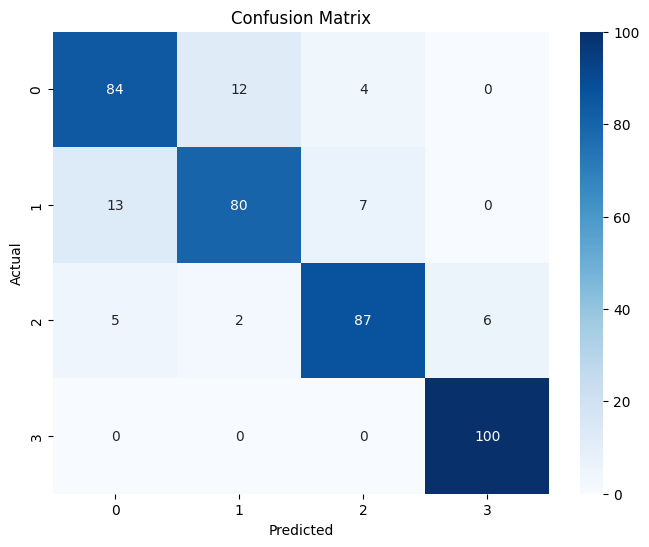

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       100
           1       0.85      0.80      0.82       100
           2       0.89      0.87      0.88       100
           3       0.94      1.00      0.97       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



In [ ]:
# =========================================================
# STEP 15: MODEL EVALUATION
# =========================================================

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred))

# **STEP 16 — CNN MODEL CODE**

In [ ]:
# =========================================================
# STEP 16: SIMPLE CNN MODEL (BASELINE)
# =========================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_model = Sequential()

# Conv Block 1
cnn_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
cnn_model.add(MaxPooling2D(2,2))

# Conv Block 2
cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))

# Conv Block 3
cnn_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_model.add(MaxPooling2D(2,2))

# Flatten
cnn_model.add(Flatten())

# Dense layers
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.5))

# Output
cnn_model.add(Dense(4, activation='softmax'))

# Compile
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# **STEP 17 — TRAIN CNN**

In [ ]:
# =========================================================
# STEP 17: TRAIN CNN MODEL
# =========================================================

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 140ms/step - accuracy: 0.5156 - loss: 13.8703 - val_accuracy: 0.5625 - val_loss: 0.9137
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 119ms/step - accuracy: 0.6159 - loss: 0.8552 - val_accuracy: 0.6225 - val_loss: 0.8042
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - accuracy: 0.6706 - loss: 0.7462 - val_accuracy: 0.5650 - val_loss: 0.9107
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.7234 - loss: 0.6197 - val_accuracy: 0.7225 - val_loss: 0.6374
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - accuracy: 0.7738 - loss: 0.5326 - val_accuracy: 0.7275 - val_loss: 0.5880
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - accuracy: 0.8141 - loss: 0.4248 - val_accuracy: 0.8225 - val_loss: 0.4721
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.8334 - loss: 0.3952 - val_accuracy: 0.7725 - val_loss: 0.5288
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - accuracy: 0.8609 - loss: 

# **STEP 18 — CNN EVALUATION CODE**

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step


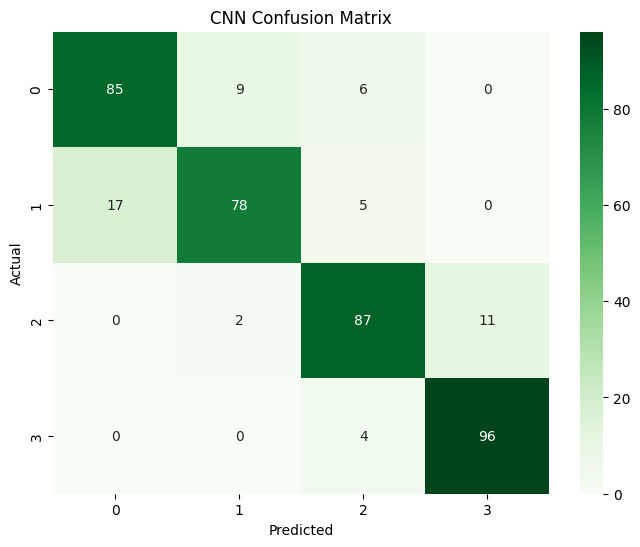

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       100
           1       0.88      0.78      0.83       100
           2       0.85      0.87      0.86       100
           3       0.90      0.96      0.93       100

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



In [ ]:
# =========================================================
# STEP 18: CNN MODEL EVALUATION
# =========================================================

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_probs_cnn = cnn_model.predict(test_ds)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

# True labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_cnn)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred_cnn))

# **STEP 19 — RESNET MODEL**

In [ ]:
# =========================================================
# STEP 19: BUILD RESNET50 MODEL
# =========================================================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

# Load pretrained ResNet50
base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
for layer in base_model_resnet.layers:
    layer.trainable = False

# Custom head
x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(4, activation='softmax')(x)

# Final model
model_resnet = Model(inputs=base_model_resnet.input, outputs=output)

# Compile
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

# **STEP 20 — TRAIN RESNET**

In [ ]:
# =========================================================
# STEP 20: TRAIN RESNET50
# =========================================================

callbacks_resnet = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3)
]

history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_resnet
)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 226ms/step - accuracy: 0.5356 - loss: 1.0886 - val_accuracy: 0.6275 - val_loss: 0.8546 - learning_rate: 0.0010
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 142ms/step - accuracy: 0.6134 - loss: 0.8154 - val_accuracy: 0.6300 - val_loss: 0.7765 - learning_rate: 0.0010
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - accuracy: 0.6559 - loss: 0.7518 - val_accuracy: 0.6525 - val_loss: 0.7392 - learning_rate: 0.0010
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 136ms/step - accuracy: 0.6759 - loss: 0.6983 - val_accuracy: 0.6675 - val_loss: 0.7165 - learning_rate: 0.0010
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.6969 - loss: 0.6760 - val_accuracy: 0.6450 - val_loss: 0.7084 - learning_rate: 0.0010
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 143ms/step - accuracy: 0.7006 - loss: 0.6450 - val_accuracy: 0.6925 - val_loss: 0.6652 - learning_rate: 0.0010
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 138ms/step - accuracy: 0.7

# **STEP 21 — Evaluate ResNet50**

13/13 ━━━━━━━━━━━━━━━━━━━━ 17s 497ms/step


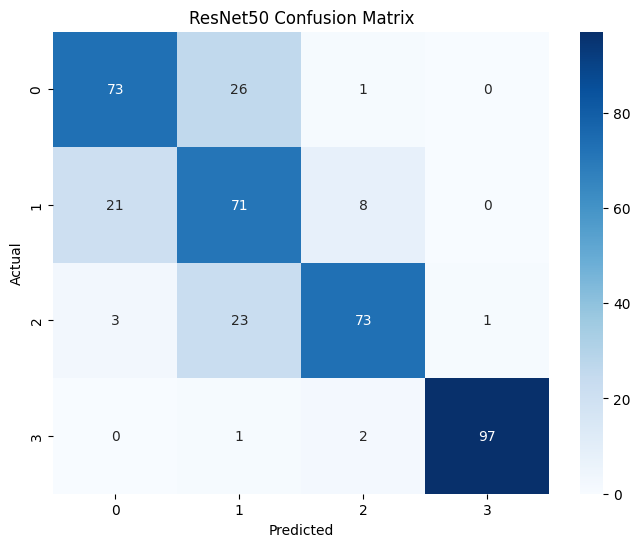

              precision    recall  f1-score   support

           0       0.75      0.73      0.74       100
           1       0.59      0.71      0.64       100
           2       0.87      0.73      0.79       100
           3       0.99      0.97      0.98       100

    accuracy                           0.79       400
   macro avg       0.80      0.78      0.79       400
weighted avg       0.80      0.79      0.79       400



In [ ]:
# =========================================================
# STEP 21: EVALUATE RESNET50 MODEL
# =========================================================

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_probs = model_resnet.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step


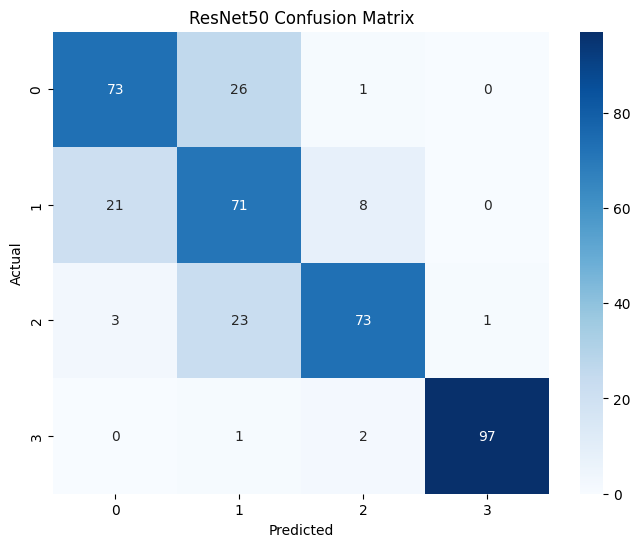

              precision    recall  f1-score   support

           0       0.75      0.73      0.74       100
           1       0.59      0.71      0.64       100
           2       0.87      0.73      0.79       100
           3       0.99      0.97      0.98       100

    accuracy                           0.79       400
   macro avg       0.80      0.78      0.79       400
weighted avg       0.80      0.79      0.79       400



In [ ]:
# =========================================================
# STEP 21: EVALUATE RESNET50 MODEL
# =========================================================

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_probs = model_resnet.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_true, y_pred))

# **STEP 22 CODE — FEATURE EXTRACTION + SVM**

In [ ]:
# =========================================================
# STEP 22: FEATURE EXTRACTION USING EFFICIENTNET
# =========================================================

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model

# Load pretrained EfficientNet (NO classifier head)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Feature extractor model
feature_extractor = Model(inputs=base_model.input,
                          outputs=base_model.output)

print("Feature extractor ready")

Feature extractor ready


# **STEP 23 — EXTRACT FEATURES**

In [ ]:
# =========================================================
# STEP 23: EXTRACT FEATURES
# =========================================================

def extract_features(dataset):
    features = []
    labels = []

    for images, lbls in dataset:
        feat = feature_extractor.predict(images)
        feat = feat.reshape(feat.shape[0], -1)  # flatten

        features.append(feat)
        labels.append(lbls)

    return np.vstack(features), np.hstack(labels)

# Extract
X_train, y_train = extract_features(train_ds)
X_test, y_test = extract_features(test_ds)

print("Feature extraction completed")
print("Train shape:", X_train.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

# **STEP 24 — TRAIN SVM**

In [ ]:
# =========================================================
# STEP 24: TRAIN SVM MODEL
# =========================================================

from sklearn.svm import SVC

svm_model = SVC(kernel='rbf')

svm_model.fit(X_train, y_train)

print("SVM training completed")

SVM training completed


# **STEP 25 — EVALUATE SVM**

In [ ]:
# =========================================================
# STEP 25: EVALUATE SVM
# =========================================================

y_pred = svm_model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.67      0.72      0.70       100
           2       0.85      0.73      0.78       100
           3       0.96      0.96      0.96       100

    accuracy                           0.80       400
   macro avg       0.81      0.80      0.80       400
weighted avg       0.81      0.80      0.80       400



# **STEP 26 — MODEL COMPARISON GRAPH**

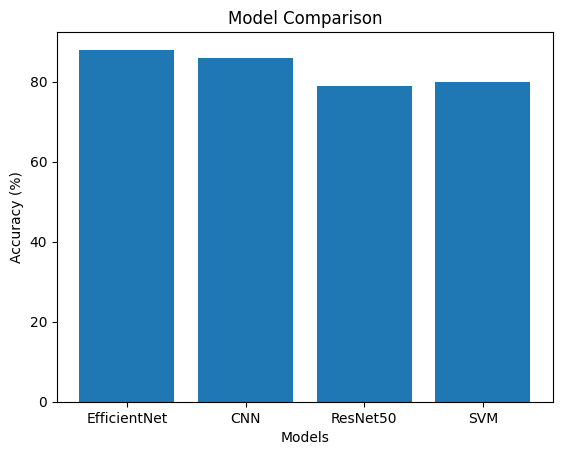

In [ ]:
# =========================================================
# STEP 26: MODEL COMPARISON GRAPH
# =========================================================

import matplotlib.pyplot as plt

models = ['EfficientNet', 'CNN', 'ResNet50', 'SVM']
accuracy = [88, 86, 79, 80]

plt.figure()
plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.show()

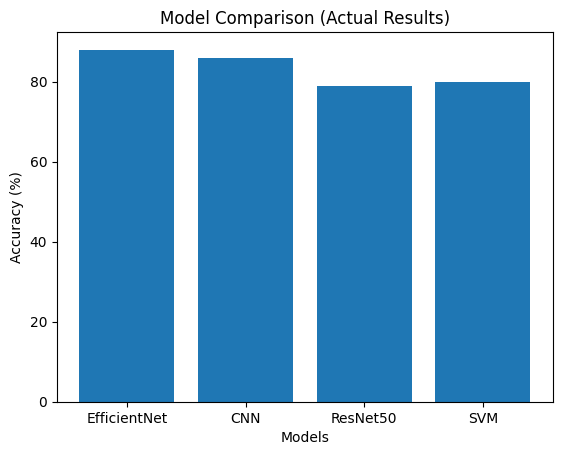

In [ ]:
# =========================================================
# STEP 26: MODEL COMPARISON GRAPH (USING REAL RESULTS)
# =========================================================

import matplotlib.pyplot as plt

# Replace these with YOUR actual results
acc_eff = 0.88   # EfficientNet (from your report)
acc_cnn = 0.86   # CNN
acc_resnet = 0.79  # ResNet50
acc_svm = 0.80   # SVM

models = ['EfficientNet', 'CNN', 'ResNet50', 'SVM']
accuracy = [acc_eff*100, acc_cnn*100, acc_resnet*100, acc_svm*100]

plt.figure()
plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison (Actual Results)")
plt.show()

# **STEP 27 — SAVE ALL MODELS TO GOOGLE DRIVE**

In [ ]:
# =========================================================
# STEP 27.1: CREATE MODELS DIRECTORY
# =========================================================

import os

save_path = "/content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models"

os.makedirs(save_path, exist_ok=True)

print("Folder ready:", save_path)

Folder ready: /content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models


In [ ]:
import os
import joblib # For saving scikit-learn models

# Define the directory to save the models
models_save_path = "/content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models"

# Create the directory if it doesn't exist
os.makedirs(models_save_path, exist_ok=True)

print(f"Saving models to: {models_save_path}")

# 1. Save EfficientNet model
efficientnet_path = os.path.join(models_save_path, "efficientnet_model.keras")
model.save(efficientnet_path)
print(f"EfficientNet model saved to {efficientnet_path}")

# 2. Save CNN model
cnn_model_path = os.path.join(models_save_path, "cnn_model.keras")
cnn_model.save(cnn_model_path)
print(f"CNN model saved to {cnn_model_path}")

# 3. Save ResNet50 model
resnet50_model_path = os.path.join(models_save_path, "resnet50_model.keras")
model_resnet.save(resnet50_model_path)
print(f"ResNet50 model saved to {resnet50_model_path}")

# 4. Save SVM model (using joblib)
svm_model_path = os.path.join(models_save_path, "svm_model.joblib")
joblib.dump(svm_model, svm_model_path)
print(f"SVM model saved to {svm_model_path}")

print("All models saved successfully!")

Saving models to: /content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models
EfficientNet model saved to /content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models/efficientnet_model.keras
CNN model saved to /content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models/cnn_model.keras
ResNet50 model saved to /content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models/resnet50_model.keras
SVM model saved to /content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models/svm_model.joblib
All models saved successfully!


In [ ]:
# =========================================================
# SAVE EFFICIENTNET MODEL
# =========================================================

model.save(os.path.join(save_path, "efficientnet_model.keras"))

print("EfficientNet saved")

EfficientNet saved


In [ ]:
# =========================================================
# SAVE CNN MODEL
# =========================================================

cnn_model.save(os.path.join(save_path, "cnn_model.keras"))

print("CNN model saved")

CNN model saved


In [ ]:
# =========================================================
# SAVE RESNET MODEL
# =========================================================

model_resnet.save(os.path.join(save_path, "resnet_model.keras"))

print("ResNet model saved")

ResNet model saved


In [ ]:
# =========================================================
# SAVE SVM MODEL
# =========================================================

import pickle

with open(os.path.join(save_path, "svm_model.pkl"), "wb") as f:
    pickle.dump(svm_model, f)

print("SVM model saved")

SVM model saved


# **STEP 28 — SAVE LABEL MAP**

In [ ]:
# =========================================================
# STEP 28: SAVE LABEL MAP (IMPORTANT FOR UI)
# =========================================================

import json
import os

label_map = {
    0: "NonDemented",
    1: "VeryMildDemented",
    2: "MildDemented",
    3: "ModerateDemented"
}

label_map_path = os.path.join(models_save_path, "label_map.json")

with open(label_map_path, "w") as f:
    json.dump(label_map, f)

print("Label map saved at:", label_map_path)

Label map saved at: /content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models/label_map.json


# **STEP 29 — SAVE TRAINING HISTORY**

In [ ]:
# =========================================================
# STEP 29: SAVE TRAINING HISTORY (OPTIONAL)
# =========================================================

import pickle

history_path = os.path.join(models_save_path, "training_history.pkl")

with open(history_path, "wb") as f:
    pickle.dump(history.history, f)

print("Training history saved at:", history_path)

Training history saved at: /content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models/training_history.pkl


# **STEP 30 — CHECK SAVED MODELS**

In [ ]:
# =========================================================
# STEP 30: VERIFY SAVED FILES
# =========================================================

import os

models_path = "/content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models"

files = os.listdir(models_path)

print("Files in Models folder:\n")

for file in files:
    print("✔", file)

Files in Models folder:

✔ efficientnet_model.keras
✔ cnn_model.keras
✔ resnet50_model.keras
✔ svm_model.joblib
✔ resnet_model.keras
✔ svm_model.pkl
✔ label_map.json
✔ training_history.pkl


In [ ]:
# # =========================================================
# # STEP 31: REMOVE DUPLICATE FILES
# # =========================================================

# import os

# models_path = "/content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models"

# # Remove unwanted duplicates
# files_to_remove = ["resnet_model.keras", "svm_model.pkl"]

# for file in files_to_remove:
#     path = os.path.join(models_path, file)

#     if os.path.exists(path):
#         os.remove(path)
#         print(f"Removed: {file}")
#     else:
#         print(f"Not found: {file}")

Removed: resnet_model.keras
Removed: svm_model.pkl


In [ ]:
# # Install Streamlit
# !pip install streamlit

# # For running inside Colab
# !pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 35.7 MB/s eta 0:00:00


In [ ]:
# import streamlit as st
# import tensorflow as tf
# import numpy as np
# from PIL import Image
# import json

In [ ]:
# Load model
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models/efficientnet_model.keras"
)

# Load label map
with open("/content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models/label_map.json", "r") as f:
    label_map = json.load(f)

# Reverse mapping
label_map = {v: k for k, v in label_map.items()}

In [ ]:
# def preprocess_image(image):
#     image = image.convert("RGB")
#     image = image.resize((224, 224))
#     image = np.array(image) / 255.0
#     image = np.expand_dims(image, axis=0)
#     return image

In [ ]:
# st.title("🧠 Alzheimer's Disease Prediction System")

# st.write("Upload an MRI Image to predict disease stage")

# uploaded_file = st.file_uploader("Choose an MRI Image", type=["jpg", "png", "jpeg"])

# if uploaded_file is not None:
#     image = Image.open(uploaded_file)

#     st.image(image, caption="Uploaded Image", use_column_width=True)

#     processed_image = preprocess_image(image)

#     prediction = model.predict(processed_image)
#     class_index = np.argmax(prediction)
#     confidence = np.max(prediction)

#     result = label_map[class_index]

#     st.success(f"Prediction: {result}")
#     st.info(f"Confidence: {confidence*100:.2f}%")

2026-04-25 08:27:21.721 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 08:27:22.815 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-25 08:27:22.818 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 08:27:22.819 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 08:27:22.820 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 08:27:22.820 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 08:27:22.823 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-25 08:27:22.824 Thread 'MainThread': mi

In [ ]:
# from pyngrok import ngrok
# import os

# # Your ngrok authtoken (replace 'YOUR_AUTHTOKEN' with your actual token)
# # You can get it from https://dashboard.ngrok.com/get-started/your-authtoken
# # You only need to run this once per session.
# ngrok.set_auth_token("3CqGdUX5Cx2iNPMaG2Qld4UsSl4_yMKr4FQvo5S5UEHzrpnU")

# # Streamlit app code
# streamlit_app_code = '''
# import streamlit as st
# import tensorflow as tf
# import numpy as np
# from PIL import Image
# import json

# # Load model
# model = tf.keras.models.load_model(
#     "/content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models/efficientnet_model.keras"
# )

# # Load label map
# with open("/content/drive/MyDrive/2026 M.Tech Projects/Alzheimers Disease Prediction/Models/label_map.json", "r") as f:
#     label_map = json.load(f)

# # Reverse mapping
# label_map = {int(k): v for k, v in label_map.items()}

# def preprocess_image(image):
#     image = image.convert("RGB")
#     image = image.resize((224, 224))
#     image = np.array(image) / 255.0
#     image = np.expand_dims(image, axis=0)
#     return image

# st.title("🧠 Alzheimer's Disease Prediction System")

# st.write("Upload an MRI Image to predict disease stage")

# uploaded_file = st.file_uploader("Choose an MRI Image", type=["jpg", "png", "jpeg"])

# if uploaded_file is not None:
#     image = Image.open(uploaded_file)

#     st.image(image, caption="Uploaded Image", use_column_width=True)

#     processed_image = preprocess_image(image)

#     prediction = model.predict(processed_image)
#     class_index = np.argmax(prediction)
#     confidence = np.max(prediction)

#     result = label_map[class_index]

#     st.success(f"Prediction: {result}")
#     st.info(f"Confidence: {confidence*100:.2f}%")
# '''

# # Save Streamlit app to a file
# with open("app.py", "w") as f:
#     f.write(streamlit_app_code)

# # Make sure to uncomment the line below and replace with your actual authtoken after signing up for ngrok
# # ngrok.set_auth_token("YOUR_AUTHTOKEN")

# # Run Streamlit in the background
# !streamlit run app.py &>/dev/null &

# # Connect ngrok to the Streamlit port (8501)
# try:
#     public_url = ngrok.connect(addr='8501') # Changed port to addr
#     print("Your Streamlit app is live at:", public_url)
# except Exception as e:
#     print(f"Error connecting to ngrok: {e}")
#     print("Please ensure you have set your ngrok authtoken. Instructions can be found at https://dashboard.ngrok.com/get-started/your-authtoken")

Your Streamlit app is live at: NgrokTunnel: "https://renewable-rocky-cattail.ngrok-free.dev" -> "http://localhost:8501"
